In [1]:
import numpy as np 

In [2]:
data =[-20,1,2,3,4,5,6,7,8,9,10]
Q1 = np.quantile(data, 0.25)
Q1

np.float64(2.5)

In [3]:
Q2 = np.quantile(data, 0.50)
Q2

np.float64(5.0)

In [4]:
Q3 = np.quantile(data, 0.75)
Q3

np.float64(7.5)

In [5]:
IQR = Q3 - Q1
IQR

np.float64(5.0)

In [6]:
minn = Q1 - 1.5  * IQR
minn

np.float64(-5.0)

In [7]:
maxx = Q3 + 1.5 * IQR
maxx

np.float64(15.0)

In [8]:
arrad_data = np.array(data)
arrad_data

array([-20,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10])

In [9]:
#########to filter the outliers

In [10]:
filtered_data = arrad_data [ (arrad_data > minn) & (arrad_data < maxx)]
print(filtered_data)

outliers = arrad_data [ (arrad_data > maxx) | (arrad_data < minn)]
print(outliers)

[ 1  2  3  4  5  6  7  8  9 10]
[-20]


In [11]:
nonOutline = np.where((arrad_data > minn) & (arrad_data < maxx), True, False)
arrad_data[nonOutline]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [12]:
arrad_data = np.where( (arrad_data > maxx) ,filtered_data.max(), arrad_data)
arrad_data = np.where( (arrad_data < minn) ,filtered_data.min(), arrad_data)
arrad_data                      
                       

array([ 1,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [13]:
import pandas as pd

In [14]:
employess = {
    "name" : ["Ahmed", "Ali", "Muna", "Reem", "Mohammed"],
    "salary" : [450, 400, 500, 2000, 50]
}
df = pd.DataFrame(employess)
df.head()



,name,salary
0,Ahmed,450
1,Ali,400
2,Muna,500
3,Reem,2000
4,Mohammed,50


In [15]:
Q1 = np.quantile(df["salary"], 0.25)
Q2 = np.quantile(df["salary"], 0.50)
Q3 = np.quantile(df["salary"], 0.75)
IQR = Q3 - Q1

LOWER = Q1 - 1.5 *IQR
UPPER = Q3 + 1.5 * IQR
print( Q1,Q2,Q3,IQR,UPPER,LOWER)

400.0 450.0 500.0 100.0 650.0 250.0


In [16]:
outliers_salary=df[(df['salary'] > UPPER) |(df['salary'] < LOWER) ]
outliers_salary


,name,salary
3,Reem,2000
4,Mohammed,50


In [17]:
noOutliers= df[(df['salary'] < UPPER) & (df['salary'] > LOWER) ]
noOutliers

,name,salary
0,Ahmed,450
1,Ali,400
2,Muna,500


In [18]:
df['salary']=np.where((df['salary'] > LOWER),noOutliers['salary'].min(), df['salary']  )
df['salary']=np.where((df['salary'] < UPPER),noOutliers['salary'].max(), df['salary']  )
df['salary']


0    500
1    500
2    500
3    500
4    500
Name: salary, dtype: int64

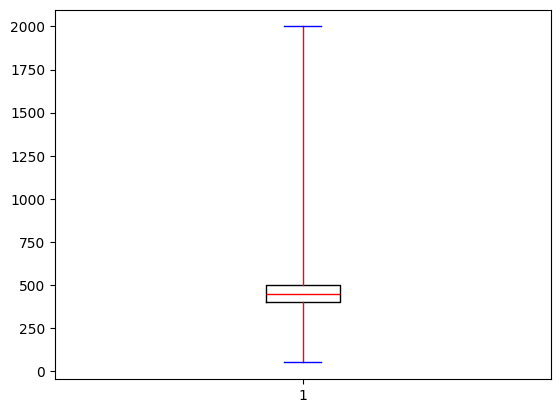

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(employess)
plt.boxplot(df['salary'].values,
           
            whis =[0,100],      #to show the whiskerprops
            medianprops=dict(color="red"),
            whiskerprops=dict(color="brown"),
            capprops=dict(color="blue")  )
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22964\3744928501.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


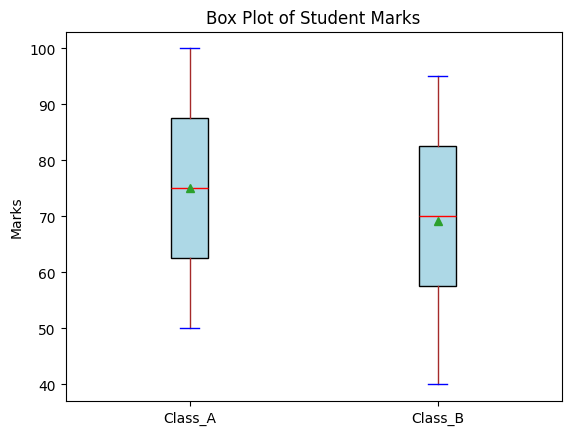

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
data = {
    "Class_A": [50, 60, 70, 80, 90, 100],
    "Class_B": [40, 55, 65, 75, 85, 95]
}

df = pd.DataFrame(data)

plt.boxplot(
    df.values,                  # data values from DataFrame (each column = one box)
    labels=df.columns,          # names for each box (Class_A, Class_B)
    patch_artist=True,         # fill boxes with color
    showmeans=True,            # show mean value as a marker
    boxprops=dict(facecolor="lightblue"),  # box color styling
    medianprops=dict(color="red"),         # median line color
    whiskerprops=dict(color="brown"),      # whiskers (lines) color
    capprops=dict(color="blu")           # caps (end lines) color
)

plt.title("Box Plot of Student Marks")   # chart title
plt.ylabel("Marks")                      # y-axis label
plt.show()